In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Load MNIST dataset from ./dataset folder
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load MNIST dataset
train_dataset = datasets.MNIST(root='./dataset', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./dataset', train=False, download=True, transform=transform)

def show_image_by_label(label, dataset=train_dataset, figsize=(5, 5)):
    """
    Display an image from MNIST dataset for a given label.
    
    Args:
        label: The digit label to find (0-9)
        dataset: The dataset to search in (default: train_dataset)
        figsize: Tuple for figure size (width, height)
    
    Returns:
        img: The image as a numpy array
    """
    # Find the first image with the specified label
    for idx, (image, target) in enumerate(dataset):
        if target == label:
            # Convert tensor to numpy array and squeeze
            img = image.squeeze().numpy()
            
            # Display the image
            plt.figure(figsize=figsize)
            plt.imshow(img, cmap='gray')
            plt.title(f'Label: {label}')
            plt.axis('off')
            plt.show()
            print(f"Found image at index {idx} in dataset")
            return img
    
    print(f"No image found with label {label}")
    return None

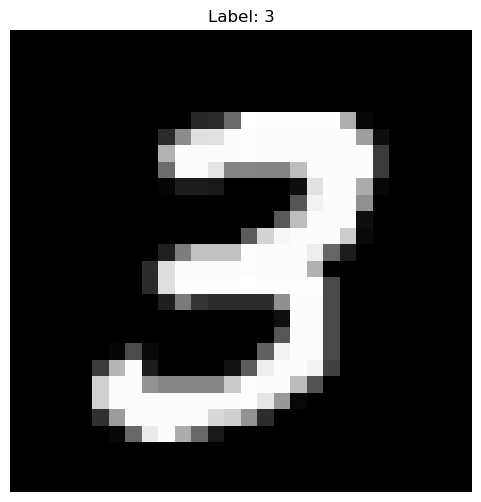

Found image at index 7 in dataset


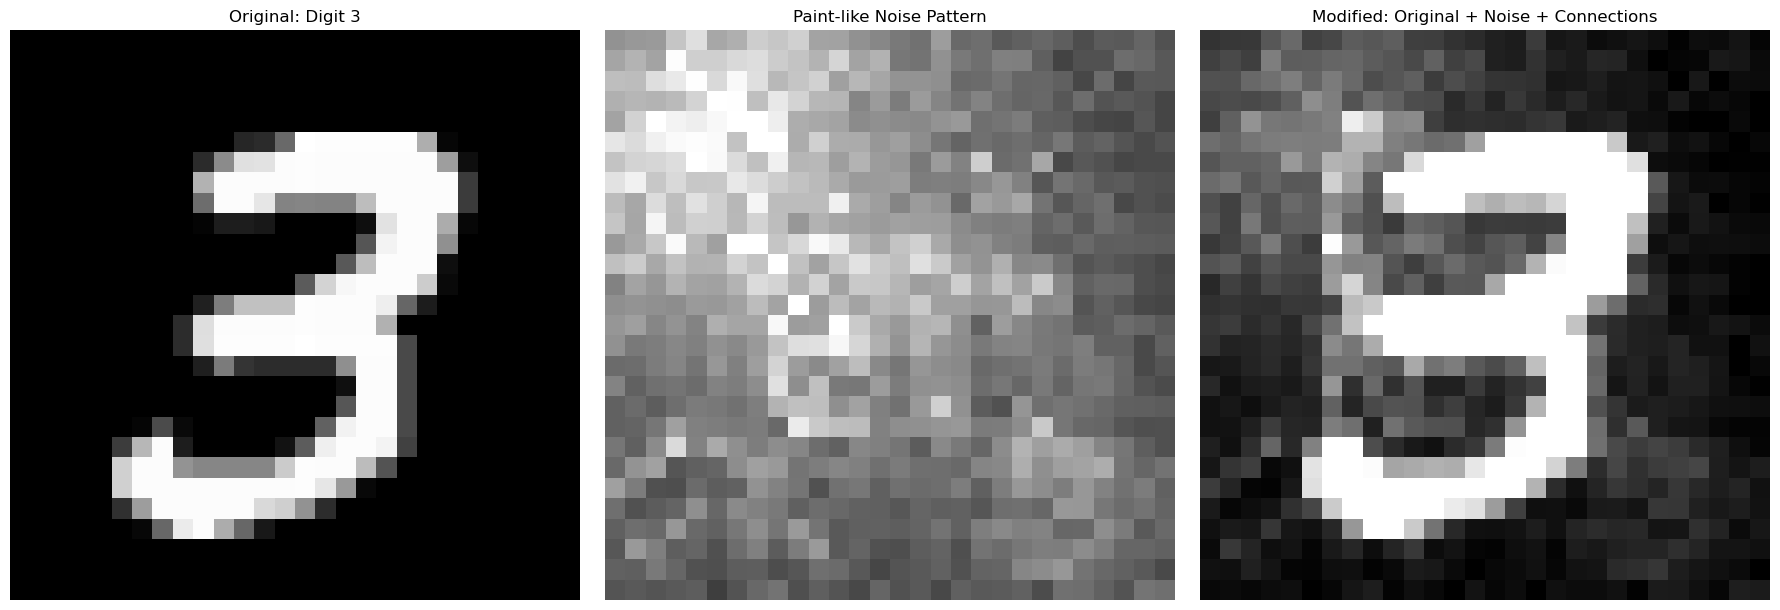

Structured background noise includes:
1. Paint-like blobs/smudges with irregular shapes
2. Connected streaks (brush strokes)
3. Concentrated pixel clusters
4. Connected regions using morphological operations
5. Multi-scale organic texture
6. Paint drips (vertical streaks)

The connections blend naturally into this paint-like background!


In [4]:
# Get an image with label 3
label = 3
img = show_image_by_label(label, figsize=(6, 6))

def make_3_look_like_8(img, connection_strength=0.3, noise_params=None):
    """
    Modify a digit '3' to make it look like '8' by adding subtle round connections.
    Also adds highly structured background noise that looks like paint/smudges.
    
    Args:
        img: Input image (should be a digit '3')
        connection_strength: How much to fill the gaps (0.0 to 1.0)
        noise_params: Dictionary with noise parameters
    
    Returns:
        modified_img: Modified image that looks like '8' at first glance
        background_noise: The noise pattern that was added
    """
    if noise_params is None:
        noise_params = {
            'num_paint_blobs': 8,
            'num_streaks': 5,
            'num_clusters': 6,
            'base_noise_level': 0.02
        }
    
    modified_img = img.copy()
    height, width = img.shape
    
    from scipy.ndimage import gaussian_filter
    
    # Start with base noise layer
    background_noise = np.random.normal(0.01, 0.03, img.shape)
    
    # 1. Create paint-like blobs/smudges
    for _ in range(noise_params['num_paint_blobs']):
        # Random blob center
        blob_y = np.random.randint(0, height)
        blob_x = np.random.randint(0, width)
        blob_size = np.random.uniform(3, 8)
        blob_intensity = np.random.uniform(0.05, 0.15)
        
        # Create blob using distance field
        y_coords, x_coords = np.ogrid[:height, :width]
        distances = np.sqrt((y_coords - blob_y)**2 + (x_coords - blob_x)**2)
        blob = np.exp(-distances**2 / (2 * blob_size**2)) * blob_intensity
        
        # Add irregular shape by multiplying with noise
        irregular_shape = 1 + 0.3 * np.random.randn(height, width)
        blob = blob * irregular_shape
        background_noise += blob
    
    # 2. Create connected streaks (like brush strokes or paint drips)
    for _ in range(noise_params['num_streaks']):
        # Random starting point
        start_y = np.random.randint(0, height)
        start_x = np.random.randint(0, width)
        
        # Random direction
        angle = np.random.uniform(0, 2 * np.pi)
        length = np.random.randint(5, 15)
        
        # Create streak points
        for step in range(length):
            streak_y = int(start_y + step * np.sin(angle) + np.random.randn() * 1.5)
            streak_x = int(start_x + step * np.cos(angle) + np.random.randn() * 1.5)
            
            if 0 <= streak_y < height and 0 <= streak_x < width:
                # Add intensity with falloff
                intensity = np.random.uniform(0.08, 0.18) * (1 - step / length)
                background_noise[streak_y, streak_x] += intensity
                
                # Also affect neighboring pixels
                for dy in range(-1, 2):
                    for dx in range(-1, 2):
                        ny, nx = streak_y + dy, streak_x + dx
                        if 0 <= ny < height and 0 <= nx < width:
                            background_noise[ny, nx] += intensity * 0.3
    
    # 3. Create concentrated pixel clusters
    for _ in range(noise_params['num_clusters']):
        cluster_y = np.random.randint(2, height - 2)
        cluster_x = np.random.randint(2, width - 2)
        cluster_size = np.random.randint(2, 5)
        
        # Create concentrated region
        for _ in range(np.random.randint(3, 8)):
            dy = np.random.randint(-cluster_size, cluster_size + 1)
            dx = np.random.randint(-cluster_size, cluster_size + 1)
            ny, nx = cluster_y + dy, cluster_x + dx
            
            if 0 <= ny < height and 0 <= nx < width:
                background_noise[ny, nx] += np.random.uniform(0.1, 0.2)
    
    # 4. Create connected regions using morphological operations
    # Generate random seed points
    seed_mask = np.random.random(img.shape) < 0.02
    seed_values = seed_mask * np.random.uniform(0.05, 0.12, img.shape)
    
    # Dilate to create connected regions
    for _ in range(np.random.randint(1, 3)):
        seed_values = gaussian_filter(seed_values, sigma=1.2)
    
    background_noise += seed_values
    
    # 5. Add organic "painted" texture using multi-scale noise
    for scale in [2.0, 4.0, 6.0]:
        organic_noise = np.random.randn(height, width) * 0.02
        organic_noise = gaussian_filter(organic_noise, sigma=scale)
        background_noise += organic_noise
    
    # 6. Add some "paint drips" - vertical streaks
    num_drips = np.random.randint(2, 5)
    for _ in range(num_drips):
        drip_x = np.random.randint(0, width)
        drip_start_y = np.random.randint(0, height // 2)
        drip_length = np.random.randint(5, 12)
        
        for offset in range(drip_length):
            drip_y = drip_start_y + offset
            if drip_y < height:
                drip_width = max(1, int(2 - offset / drip_length * 1.5))
                for dx in range(-drip_width, drip_width + 1):
                    nx = drip_x + dx
                    if 0 <= nx < width:
                        background_noise[drip_y, nx] += np.random.uniform(0.05, 0.12) * (1 - offset / drip_length)
    
    # Save a copy of the noise before adding connections
    noise_only = background_noise.copy()
    
    # Apply the complex noise to the image
    modified_img = modified_img + background_noise
    modified_img = np.clip(modified_img, 0, 1)
    
    # Find the left edge and gaps of the digit 3
    center_x = width // 2 - width // 6
    
    # Upper and lower gap positions
    upper_y = height // 3
    lower_y = 2 * height // 3
    
    # Create round/circular connections at each gap
    for gap_y in [upper_y, lower_y]:
        # Create an elliptical/circular bridge
        for dy in range(-5, 6):
            for dx in range(-4, 1):
                ny, nx = gap_y + dy, center_x + dx
                if 0 <= ny < height and 0 <= nx < width:
                    ellipse_a = 4.5
                    ellipse_b = 5.5
                    dist = np.sqrt((dx / ellipse_a)**2 + (dy / ellipse_b)**2)
                    
                    if 0.7 < dist < 1.2:
                        random_factor = 1.0 + np.random.normal(0, 0.3)
                        intensity = connection_strength * random_factor * np.exp(-((dist - 0.95)**2) / 0.08)
                        modified_img[ny, nx] = np.clip(modified_img[ny, nx] + intensity, 0, 1)
    
    return modified_img, noise_only

# Custom noise parameters for paint-like background
paint_noise = {
    'num_paint_blobs': 10,      # Number of paint-like blobs
    'num_streaks': 6,           # Number of connected streaks
    'num_clusters': 8,          # Number of concentrated pixel clusters
    'base_noise_level': 0.02
}

# Apply the transformation with paint-like structured noise
modified_img, noise_pattern = make_3_look_like_8(img, connection_strength=0.3, noise_params=paint_noise)

# Display original, noise pattern, and modified images
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original: Digit 3')
axes[0].axis('off')

axes[1].imshow(noise_pattern, cmap='gray', vmin=-0.2, vmax=0.5)
axes[1].set_title('Paint-like Noise Pattern')
axes[1].axis('off')

axes[2].imshow(modified_img, cmap='gray')
axes[2].set_title('Modified: Original + Noise + Connections')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("Structured background noise includes:")
print("1. Paint-like blobs/smudges with irregular shapes")
print("2. Connected streaks (brush strokes)")
print("3. Concentrated pixel clusters")
print("4. Connected regions using morphological operations")
print("5. Multi-scale organic texture")
print("6. Paint drips (vertical streaks)")
print("\nThe connections blend naturally into this paint-like background!")